In [9]:
# for data
from neo4j import GraphDatabase
import pandas as pd

# for clustering
import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from community import community_louvain

auth_data = pd.read_csv('../api_creds/neo4j_creds_gsv3.csv')

uri = auth_data['uri'].values[0]
username = auth_data['username'].values[0]
password = auth_data['password'].values[0]

driver = GraphDatabase.driver(uri, auth=(username, password))

In [10]:
KEEP_FIELDS = [
    'event_title',
    'performers',
    'entity',
    'location'
]

def simplify_results(results):

    simplified = []

    for record in results:
        simplified.append({
            k: record.get(k)
            for k in KEEP_FIELDS
        })

    return simplified

In [11]:
def get_data():

    cypher_query = """

    MATCH (e:Event)-[]-(l:Location)
    MATCH (e)-[:MENTIONS]-(entity:Entity)
    WHERE toLower(entity.name) =~ '.*(record.*|vinyl.*|music exchange.*|record exchange.*|music shop.*|music store.*|record shop.*|record store.*|vinyl shop.*|vinyl store.*).*'
    AND l.name IN [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
        'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
        'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
        'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
        'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri',
        'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey',
        'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio',
        'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
        'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
        'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
    ]
    RETURN
        split(e.event_text, '\n')[0] AS event_title,
        split(e.event_text, '\n')[3] AS performers,
        entity.name AS entity,
        l.name AS location
    ORDER BY e.date_added DESC

    """

    driver = GraphDatabase.driver(uri, auth=(username, password))

    with driver.session() as session:
        data = list(session.run(cypher_query))

    data = list(data)
    data = simplify_results(data)
    event_df = pd.DataFrame(data)
    return event_df

In [17]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

# Let's Go

In [18]:
event_df = get_data()
event_df['cluster'] = cluster_text(event_df['event_title'])
event_df.head()

,event_title,performers,entity,location,cluster
0,COVEX | EDM DJ Music Concert Show,Covex,Club Vinyl,Colorado,0
1,The Well with Moon Destroys,"The Well, Moon Destroys, Grim Trophies",Riding Easy Records,Texas,1
2,Factory 93 Presents: Hot Meal Records @ Ace*Mi...,"Bad Boombox, Mad Gavs, Mischluft, Ollie Lishma...",Hot Meal Records,California,2
3,Record Club,Not provided in source.,Record Club,Washington,3
4,🍍 PINEAPPLE THURSDAYS: PRE-HALLOWEEN EDITION 🍍,"No_One, Jehnee, JohnyVinyl, Velvet Pistol b2b ...",JohnyVinyl,California,4


# Inspect Clusters

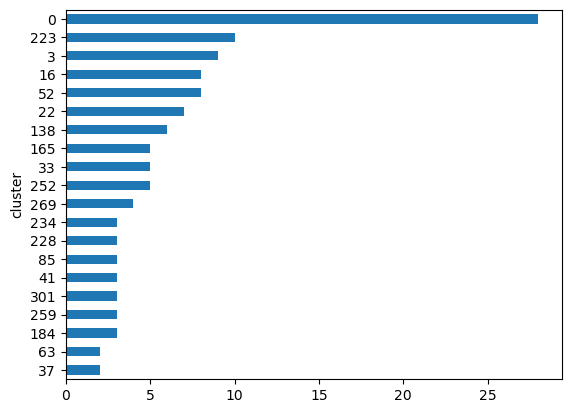

In [21]:
event_df['cluster'].value_counts()[0:20].plot.barh().invert_yaxis()

# Inspect Clusters Textually, From Largest to Smallest

In [28]:
for cluster in event_df['cluster'].value_counts().index[0:10]: # take off the [0:10] for full list; blog only gets sample
    print('\nCLUSTER:', cluster)
    print()

    cluster_df = event_df[event_df['cluster'] == cluster].sort_values('event_title')

    for _, row in cluster_df.iterrows():
        print('{} ({}, {}, {})'.format(
            row['event_title'],
            row['performers'],
            row['entity'],
            row['location']
        ))


CLUSTER: 0

4B | EDM DJ Music Concert Show (4B, Club Vinyl, Colorado)
Ahadadream | EDM DJ Music Concert Show (Ahadadream, Club Vinyl, Colorado)
Angrybaby | EDM DJ Music Concert Show (Angrybaby, Club Vinyl, Colorado)
Bassjackers | EDM DJ Music Concert Show (Bassjackers, Club Vinyl, Colorado)
Buunshin | EDM DJ Music Concert Show (Buunshin, Club Vinyl, Colorado)
COVEX | EDM DJ Music Concert Show (Covex, Club Vinyl, Colorado)
Cinthie | EDM DJ Music Concert Show (Cinthie, Club Vinyl, Colorado)
Cyril | EDM DJ Music Concert Show (Cyril, Club Vinyl, Colorado)
EMBRZ | EDM DJ Music Concert Show (EMBRZ, Club Vinyl, Colorado)
Elephante | EDM DJ Music Concert Show  (Elephante, Club Vinyl, Colorado)
Grafix | EDM DJ Music Concert Show (Grafix, Club Vinyl, Colorado)
HVDES | EDM DJ Music Concert Show (HVDES, Club Vinyl, Colorado)
INVT | EDM DJ Music Concert Show (INVT, Club Vinyl, Colorado)
Jamback | EDM DJ Music Concert Show (Jamback, Club Vinyl, Colorado)
Jerro | EDM DJ Music Concert Show (Jerro, Cl